In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [ ]:
df = pd.read_csv("/net/nwgc/vol1/nobackup/czaka/mitoscope/smaht/hapmap/hprc_truthset_eval/vs_SR/combined_tables/HPRC.vcfeval.by_sample.all.tsv", sep='\t')
df_long = pd.melt(df,
                  id_vars=['tool', 'tech', 'sample'],  # Columns to keep as identifier variables
                  var_name='Metric',   # Name for the new column holding the original column names
                  value_name='Value')

df_long['Metric'] = df_long['Metric'].replace({
    'precision': 'Precision',
    'sensitivity': 'Sensitivity',
    'f_measure': 'F1'
})

df_long 


,tool,tech,sample,Metric,Value
0,mitoscope,pacbio,hapmap-pacbio-bcm,true_positives_baseline,1.0000
1,mitoscope,pacbio,hapmap-pacbio-broad,true_positives_baseline,1.0000
2,mitoscope,pacbio,hapmap-pacbio-uwsc,true_positives_baseline,1.0000
3,mitoscope,pacbio,hapmap-pacbio-washu,true_positives_baseline,1.0000
4,mitoscope,ont,hapmap-ont-bcm,true_positives_baseline,1.0000
...,...,...,...,...,...
149,mitorsaw,pacbio,hapmap-pacbio-washu,F1,0.0000
150,mutect2,illumina,hapmap-illumina-bcm,F1,0.1818
151,mutect2,illumina,hapmap-illumina-broad,F1,0.1739
152,mutect2,illumina,hapmap-illumina-nygc,F1,0.0976


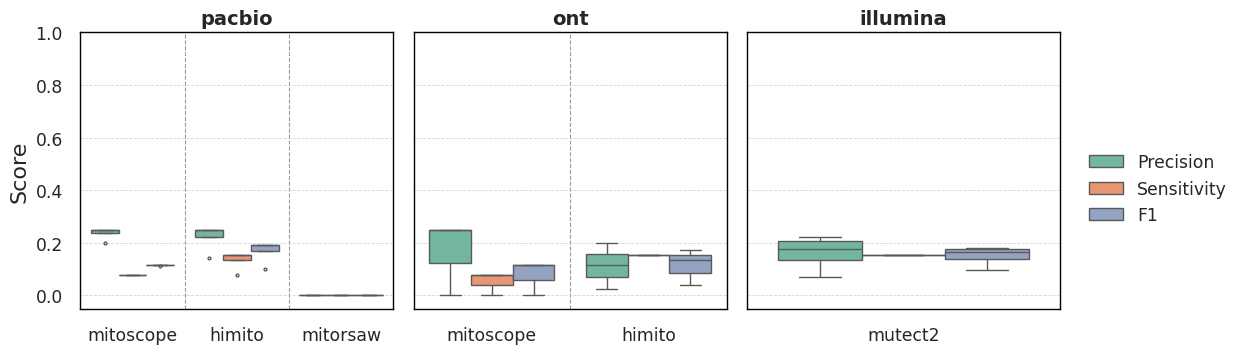

In [ ]:

sns.set_theme(style="whitegrid", context="talk", font_scale=0.75)

# Define custom colors (optional, can adjust to fit your theme)
palette = sns.color_palette("Set2", n_colors=3)

g = sns.catplot(
    data=df_long[df_long['Metric'].isin(['Precision', 'Sensitivity', 'F1'])],
    x="tool",
    y="Value",
    col="tech",
    col_wrap=4,
    hue="Metric",
    kind="box",
    height=4,
    aspect=0.9,
    palette=palette,
    linewidth=1,
    fliersize=2,
    #legend_out=False,
    sharex=False,
    sharey=True,
    
)
sns.move_legend(g, "center right", bbox_to_anchor=(0.8,0.5), title="") 
#sns.move_legend(g, "lower center", ncol=3, title="") 

g.tick_params(axis='x', labelrotation=360)
g.set_titles("{col_name}", size=14, weight='bold')
g.set_axis_labels("", "Score", size=16)
g.set(ylim=(-0.05, 1))

for ax in g.axes.flat:
    sns.despine(ax=ax, left=False, right=False, bottom=False, top=False)  # keep full axes box
    ax.grid(True, axis='y', linestyle='--', linewidth=0.6, alpha=0.8)

    # Get tick positions (x coordinates of categories)
    ticks = ax.get_xticks()

    # Compute midpoints between categories
    if len(ticks) > 1:
        midpoints = [(ticks[i] + ticks[i+1]) / 2 for i in range(len(ticks)-1)]
        for x in midpoints:
            ax.axvline(
                x=x,
                color="gray",
                linestyle="--",
                linewidth=0.8,
                alpha=0.8,
                zorder=0,   # keeps lines behind boxes
            )

    
    for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1)
            spine.set_color("black")

#plt.savefig("plots/hapmap.benchmarking.bytech.indels.png", dpi=300)
plt.show()




In [5]:
## plot of mitoscope heteroplasmy levels vs mutect 2 heteroplasmy levels (correlation plot or heat map w R2 value?)
## using mean het values across sites 

mutect_df = pd.read_csv('/net/nwgc/vol1/nobackup/czaka/mutect2/smaht/illumina/output/merged.mutect2.vcfeval.vcf.gz', 
                 comment='#', sep='\t', compression='gzip', names=['chrom', 'pos', 'id', 'ref', 'alt', 'qual', 'filter', 'info', 'format', 'sample'])

mutect_df['id'] = mutect_df[['chrom', 'pos', 'ref', 'alt']].astype(str).agg('-'.join, axis=1)
mutect_df['hp_mutect'] = mutect_df['info'].str.extract(r'AVG_HET=([0-9.]+);').astype(float)
mutect_df['tool'] = 'mutect2'
mutect_df['tech'] = 'illumina'
mutect_df = mutect_df[['id', 'hp_mutect']]
mutect_df


,id,hp_mutect
0,MT-34-G-T,0.005568
1,MT-73-A-G,0.963500
2,MT-106-G-A,0.026250
3,MT-141-C-T,0.001112
4,MT-150-C-T,0.097750
...,...,...
300,MT-16470-G-A,0.001160
301,MT-16488-C-T,0.004254
302,MT-16503-G-A,0.001906
303,MT-16519-T-C,0.841750


In [6]:
mitoscope_pb_df = pd.read_csv('/net/nwgc/vol1/nobackup/czaka/mitoscope/smaht/hapmap/pacbio/output/merged.baldur.vcfeval.vcf.gz', 
                 comment='#', sep='\t', compression='gzip', names=['chrom', 'pos', 'id', 'ref', 'alt', 'qual', 'filter', 'info', 'format', 'sample'])

mitoscope_pb_df['id'] = mitoscope_pb_df[['chrom', 'pos', 'ref', 'alt']].astype(str).agg('-'.join, axis=1)
mitoscope_pb_df['hp_mito_pb'] = mitoscope_pb_df['info'].str.extract(r'AVG_HET=([0-9.]+);').astype(float)
mitoscope_pb_df['tool'] = 'mitoscope'
mitoscope_pb_df['tech'] = 'pacbio'
mitoscope_pb_df = mitoscope_pb_df[['id', 'hp_mito_pb']]

mitoscope_pb_df

,id,hp_mito_pb
0,MT-73-A-G,0.957632
1,MT-106-G-A,0.026638
2,MT-150-C-T,0.114118
3,MT-185-G-A,0.928995
4,MT-246-TG-T,0.811205
...,...,...
123,MT-16304-T-C,0.830305
124,MT-16325-T-C,0.027498
125,MT-16327-C-T,0.026695
126,MT-16488-C-T,0.003405


In [7]:
mitoscope_ont_df = pd.read_csv('/net/nwgc/vol1/nobackup/czaka/mitoscope/smaht/hapmap/ont/output/merged.baldur.vcfeval.vcf.gz', 
                 comment='#', sep='\t', compression='gzip', names=['chrom', 'pos', 'id', 'ref', 'alt', 'qual', 'filter', 'info', 'format', 'sample'])

mitoscope_ont_df['id'] = mitoscope_ont_df[['chrom', 'pos', 'ref', 'alt']].astype(str).agg('-'.join, axis=1)
mitoscope_ont_df['hp_mito_ont'] = mitoscope_ont_df['info'].str.extract(r'AVG_HET=([0-9.]+);').astype(float)
mitoscope_ont_df['tool'] = 'mitoscope'
mitoscope_ont_df['tech'] = 'ont'
mitoscope_ont_df = mitoscope_ont_df[['id', 'hp_mito_ont']]

mitoscope_ont_df

,id,hp_mito_ont
0,MT-73-A-G,0.976870
1,MT-106-G-A,0.038517
2,MT-150-C-T,0.096020
3,MT-185-G-A,0.917963
4,MT-246-TG-T,0.815557
...,...,...
125,MT-16325-T-C,0.036837
126,MT-16327-C-T,0.029223
127,MT-16374-AC-A,0.042220
128,MT-16488-C-T,0.003310


In [8]:
himito_pb_df = pd.read_csv('/net/nwgc/vol1/nobackup/czaka/himito/smaht/hapmap/pacbio/output/merged.himito.vcfeval.vcf.gz', 
                 comment='#', sep='\t', compression='gzip', names=['chrom', 'pos', 'id', 'ref', 'alt', 'qual', 'filter', 'info', 'format', 'sample'])

himito_pb_df['id'] = himito_pb_df[['chrom', 'pos', 'ref', 'alt']].astype(str).agg('-'.join, axis=1)
himito_pb_df['hp_himito_pb'] = himito_pb_df['info'].str.extract(r'AVG_HET=([0-9.]+);').astype(float)
himito_pb_df['tool'] = 'himito'
himito_pb_df['tech'] = 'pacbio'
himito_pb_df = himito_pb_df[['id', 'hp_himito_pb']]

himito_pb_df

,id,hp_himito_pb
0,MT-73-A-G,0.954861
1,MT-106-G-A,0.027173
2,MT-150-C-T,0.110371
3,MT-185-G-A,0.921026
4,MT-246-TG-T,0.808204
...,...,...
106,MT-16301-C-T,0.113340
107,MT-16304-T-C,0.829745
108,MT-16325-T-C,0.026597
109,MT-16327-C-T,0.026597


In [9]:
himito_ont_df = pd.read_csv('/net/nwgc/vol1/nobackup/czaka/himito/smaht/hapmap/ont/output/merged.himito.vcfeval.vcf.gz', 
                 comment='#', sep='\t', compression='gzip', names=['chrom', 'pos', 'id', 'ref', 'alt', 'qual', 'filter', 'info', 'format', 'sample'])

himito_ont_df['id'] = himito_ont_df[['chrom', 'pos', 'ref', 'alt']].astype(str).agg('-'.join, axis=1)
himito_ont_df['hp_himito_ont'] = himito_ont_df['info'].str.extract(r'AVG_HET=([0-9.]+);').astype(float)
himito_ont_df['tool'] = 'himito'
himito_ont_df['tech'] = 'ont'
himito_ont_df = himito_ont_df[['id', 'hp_himito_ont']]

himito_ont_df

,id,hp_himito_ont
0,MT-65-TG-T,0.051745
1,MT-70-G-C,0.027185
2,MT-71-GTA-G,0.028387
3,MT-73-A-G,0.935343
4,MT-106-G-A,0.022953
...,...,...
200,MT-16374-AC-A,0.027318
201,MT-16383-A-G,0.020790
202,MT-16387-A-C,0.023692
203,MT-16431-CA-C,0.024604


In [10]:
mitorsaw_pb_df = pd.read_csv('/net/nwgc/vol1/nobackup/czaka/mitorsaw/smaht/pacbio/output/merged.mitorsaw.vcfeval.vcf.gz', 
                 comment='#', sep='\t', compression='gzip', names=['chrom', 'pos', 'id', 'ref', 'alt', 'qual', 'filter', 'info', 'format', 'sample'])

mitorsaw_pb_df['id'] = mitorsaw_pb_df[['chrom', 'pos', 'ref', 'alt']].astype(str).agg('-'.join, axis=1)
mitorsaw_pb_df['hp_mitorsaw_pb'] = mitorsaw_pb_df['info'].str.extract(r'AVG_HET=([0-9.]+);').astype(float)
mitorsaw_pb_df['tool'] = 'mitorsaw'
mitorsaw_pb_df['tech'] = 'pb'
mitorsaw_pb_df = mitorsaw_pb_df[['id', 'hp_mitorsaw_pb']]

In [11]:
merged_df = pd.merge(mutect_df, mitoscope_pb_df, on="id", how="inner")
final_merged_df = pd.merge(merged_df, mitoscope_ont_df, on="id", how="inner")
#merged_df3 = pd.merge(merged_df2, himito_pb_df, on="id", how="outer")
#merged_df4 = pd.merge(merged_df3, himito_ont_df, on="id", how="outer")
#final_merged_df = pd.merge(merged_df3, mitorsaw_pb_df, on="id", how="outer")

final_merged_df['ref'] = final_merged_df['id'].str.split("-", expand=True)[2]
final_merged_df['alt'] = final_merged_df['id'].str.split("-", expand=True)[3]

final_merged_df['indel'] = final_merged_df.apply(lambda row: 'indel' if (len(row['ref']) > 1 or len(row['alt']) > 1) else 'snv', axis=1)
final_merged_df = final_merged_df.drop(columns=['ref','alt'])

final_merged_df

#final_merged_df = final_merged_df[final_merged_df['indel'] == 'snv']

,id,hp_mutect,hp_mito_pb,hp_mito_ont,indel
0,MT-73-A-G,0.963500,0.957632,0.976870,snv
1,MT-106-G-A,0.026250,0.026638,0.038517,snv
2,MT-150-C-T,0.097750,0.114118,0.096020,snv
3,MT-185-G-A,0.935750,0.928995,0.917963,snv
4,MT-246-TG-T,0.839750,0.811205,0.815557,indel
...,...,...,...,...,...
115,MT-16304-T-C,0.880000,0.830305,0.880123,snv
116,MT-16325-T-C,0.026750,0.027498,0.036837,snv
117,MT-16327-C-T,0.027750,0.026695,0.029223,snv
118,MT-16488-C-T,0.004254,0.003405,0.003310,snv


In [12]:
corr = final_merged_df.drop(columns=['id', 'indel']).corr()
corr


,hp_mutect,hp_mito_pb,hp_mito_ont
hp_mutect,1.000000,0.959323,0.958569
hp_mito_pb,0.959323,1.000000,0.998902
hp_mito_ont,0.958569,0.998902,1.000000


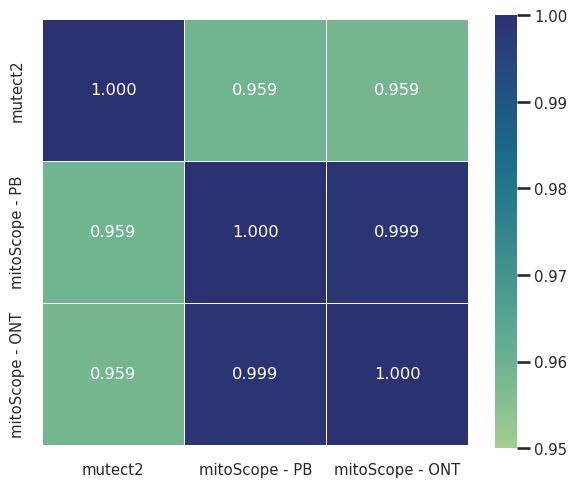

In [13]:
sns.set_theme(style="whitegrid", context="talk", font_scale=0.65)
labels=['mutect2', 'mitoScope - PB', 'mitoScope - ONT']

plt.figure(figsize=(6, 5))
sns.heatmap(corr, xticklabels=labels, yticklabels=labels, annot=True, cmap="crest", vmin=0.95, vmax=1, square=True, fmt=".3f", linewidth=.5)
#plt.title("Correlation of heteroplasmy levels across tools")
plt.tight_layout()


plt.savefig("plots/hapmap.benchmarking.concordance.heatmap.png", dpi=300)
plt.show()

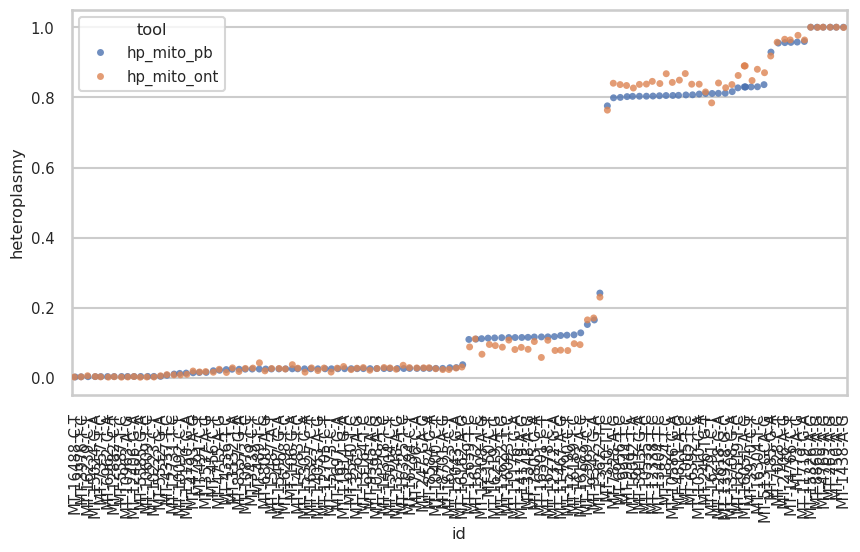

In [ ]:
#melt to long format
high_het = final_merged_df[(final_merged_df['hp_mito_pb'] > 0)][['id', 'hp_mito_pb', 'hp_mito_ont', 'indel']]
high_het = high_het.sort_values("hp_mito_pb")
long = high_het.melt(id_vars=["id","indel"], var_name="tool", value_name="heteroplasmy")
#long["category"] = pd.cut(long["heteroplasmy"], bins=[0, 0.5, 1], labels=["Low", "High"])

long

plt.figure(figsize=(10,5))
sns.stripplot(long, x='id', y='heteroplasmy', hue='tool',size=5,alpha=0.8)
#plt.yscale('log')
#plt.ylim(0,0.05)
plt.tick_params(axis='x', labelrotation=90)


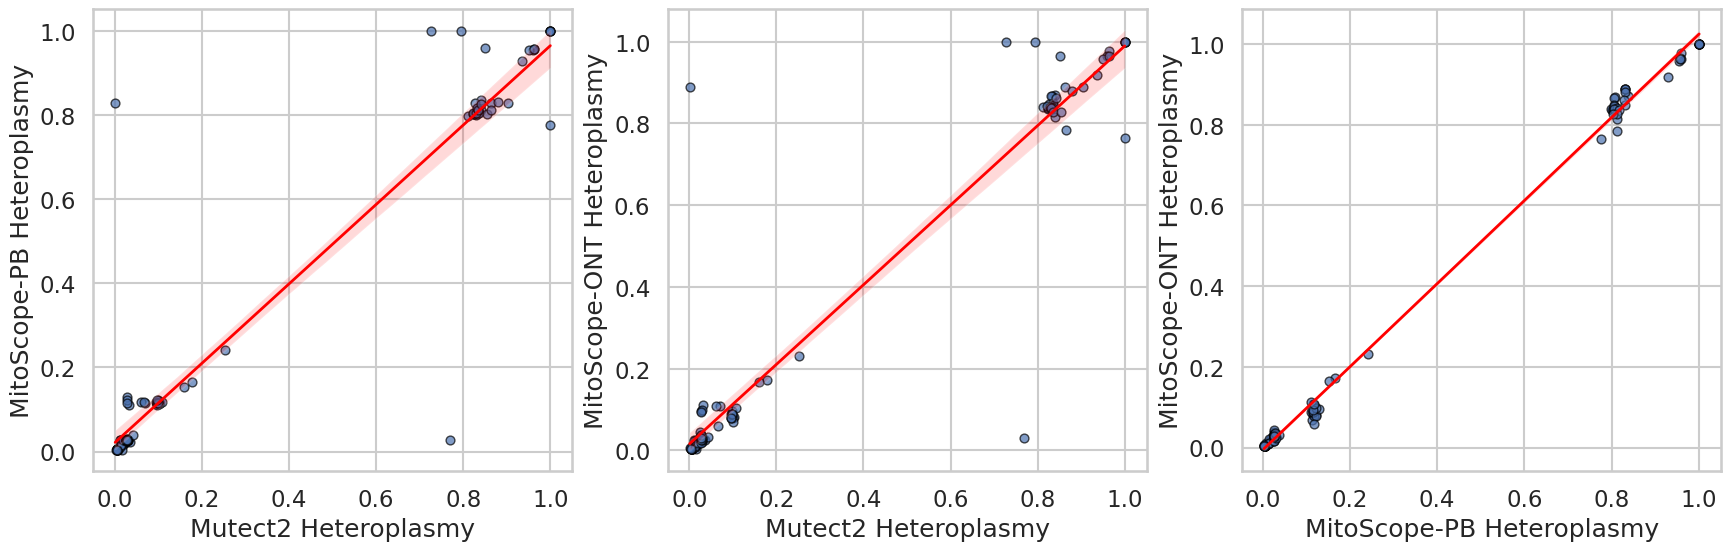

In [15]:

# Set global style for publication
sns.set_theme(style="whitegrid", context="talk", font_scale=1)

# Create figure with 3 panels side-by-side
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Define common styling parameters
common_kws = dict(scatter_kws={'s': 40, 'alpha': 0.7, 'edgecolor': 'black'},
                  line_kws={'color': 'red', 'lw': 2})

sns.regplot(data=final_merged_df, x='hp_mutect', y='hp_mito_pb', ax=axes[0], **common_kws)
axes[0].set_xlabel('Mutect2 Heteroplasmy')
axes[0].set_ylabel('MitoScope-PB Heteroplasmy')

sns.regplot(data=final_merged_df, x='hp_mutect', y='hp_mito_ont', ax=axes[1], **common_kws)
axes[1].set_xlabel('Mutect2 Heteroplasmy')
axes[1].set_ylabel('MitoScope-ONT Heteroplasmy')

sns.regplot(data=final_merged_df, x='hp_mito_pb', y='hp_mito_ont', ax=axes[2], **common_kws)
axes[2].set_xlabel('MitoScope-PB Heteroplasmy')
axes[2].set_ylabel('MitoScope-ONT Heteroplasmy')

plt.savefig("plots/hapmap.benchmarking.concordance.regplot.png", dpi=300, bbox_inches='tight')
plt.show()



In [16]:
final_merged_df['pos'] = final_merged_df['id'].str.split('-', expand=True)[1].astype(int)
final_merged_df[(final_merged_df['pos'] > 308) & (final_merged_df['pos'] < 312)]

,id,hp_mutect,hp_mito_pb,hp_mito_ont,indel,pos
7,MT-310-T-TC,0.99975,0.775948,0.763735,indel,310


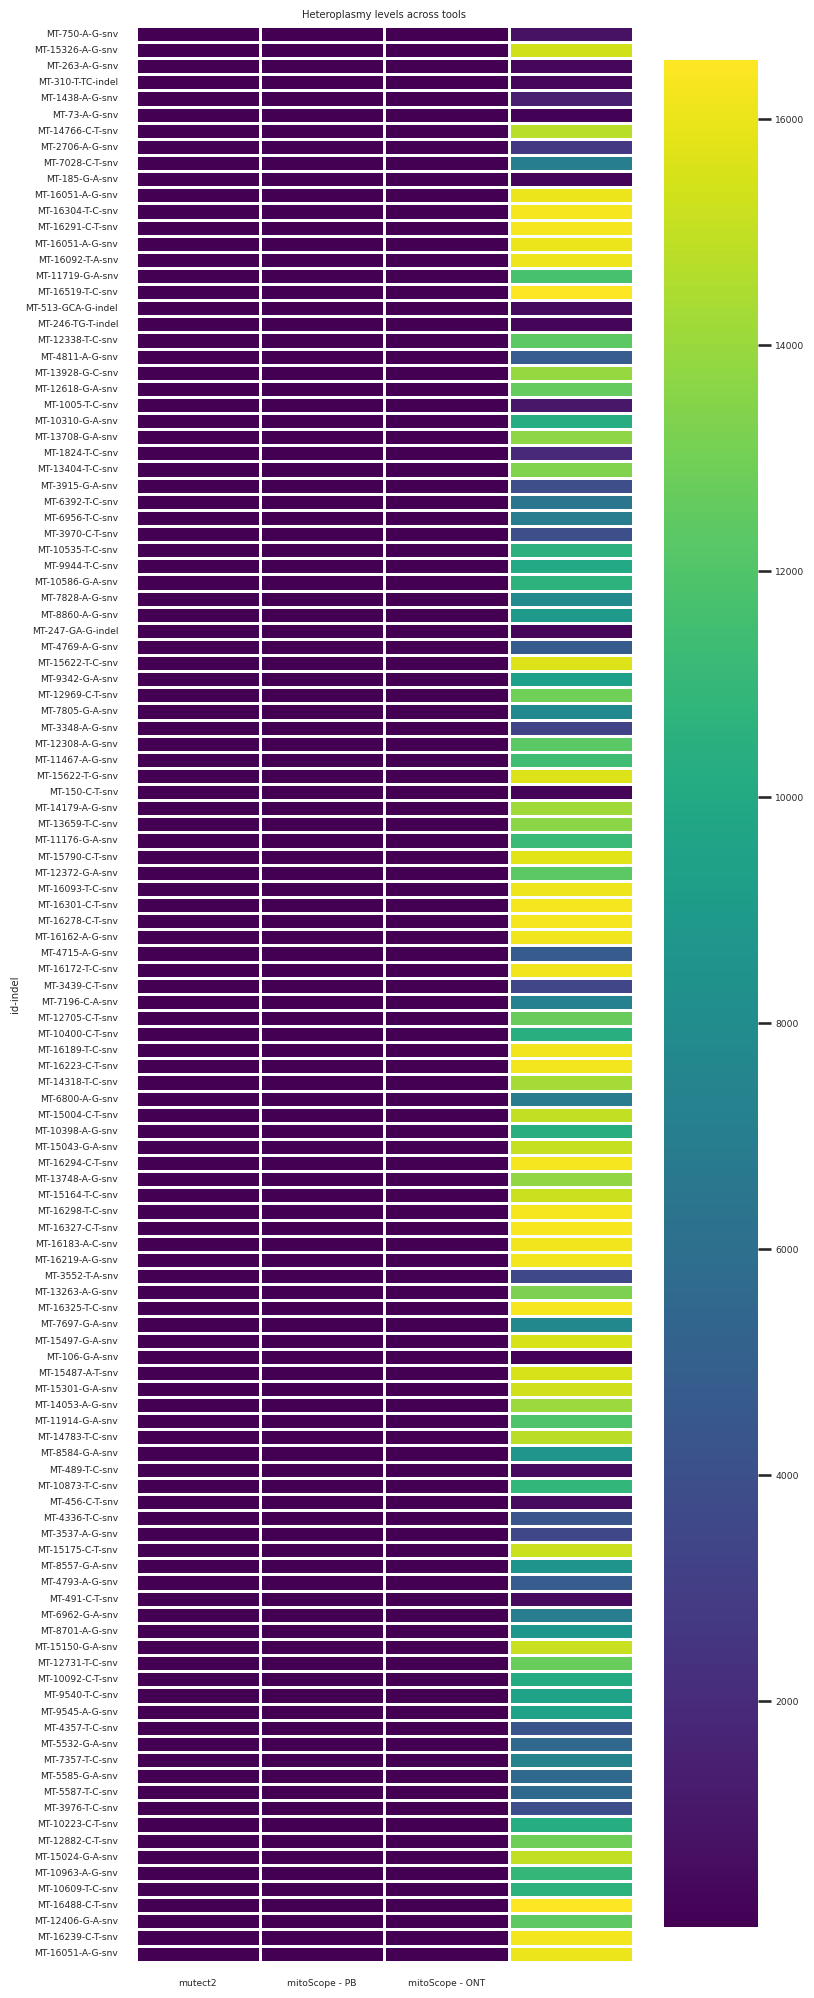

In [17]:

sns.set_theme(style="whitegrid", context="talk", font_scale=0.4)
labels=['mutect2', 'mitoScope - PB', 'mitoScope - ONT']
df_sorted = final_merged_df.sort_values("hp_mutect", ascending=False)

plt.figure(figsize=(8, 20))
sns.heatmap(df_sorted.set_index(["id", "indel"]), xticklabels=labels, annot=False, cmap="viridis", linewidths=1, fmt=".3f")
plt.title("Heteroplasmy levels across tools")
plt.tight_layout()

plt.savefig("plots/hapmap.benchmarking.concordance.heatmap.png", dpi=300)
plt.show()